In [36]:
# data cleaning and visualization imports
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# scikitlearn imports
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_predict

# modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC


# métricas
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [3]:
TRAIN_PATH_RAW = '../data/raw/train.csv'

def load_kaggle_data(caminho_do_arquivo):
    caminho = Path(caminho_do_arquivo)

    if not caminho.exists():
        raise FileNotFoundError(
        f"Arquivo não encontrado no caminho: {caminho.resolve()}")
    
    df = pd.read_csv(caminho)

    target = 'Will_Buy_EV'

    if target in df.columns:
        df[target] = df[target].map({'Yes': 1, 'No': 0})

    return df

In [4]:
train = load_kaggle_data(TRAIN_PATH_RAW)
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0


In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  str    
 9   City_Type                    668665 non-null  str    
 10  Current_Car_Type             668665 non-null  str    
 11  Home_Charging_Possible       668665 non-null  str    
 12  Subsidy_Available            668665 non-null  str    
 13  Range_Anxi

valores unicos de colunas categóricas

In [7]:
cat_col = ['Gender', 'City_Type', 'Current_Car_Type',
         'Home_Charging_Possible', 'Subsidy_Available', 'Range_Anxiety_Level']

num_col = ['Age', 'Annual_Income_USD', 'Daily_Commute_km',
       'Number_of_Cars_Owned', 'Charging_Stations_Near_Home',
       'Charging_Stations_Near_Work', 'Environmental_Concern_Level', 'Will_Buy_EV']


def show_cat_unique(df, colunas):
    for col in colunas:
        print(f'valores únicos da coluna: {col}')
        print(list(df[col].unique()))
        print(50*'=')

show_cat_unique(train, cat_col)

valores únicos da coluna: Gender
['Male', 'Female', 'Other']
valores únicos da coluna: City_Type
['Suburban', 'Rural', 'Urban']
valores únicos da coluna: Current_Car_Type
['Sedan', 'SUV', 'Hatchback', 'Truck']
valores únicos da coluna: Home_Charging_Possible
['Yes', 'No']
valores únicos da coluna: Subsidy_Available
['No', 'Yes']
valores únicos da coluna: Range_Anxiety_Level
['Low', 'Medium', 'High']


In [8]:
train_num = train[num_col]
train_num.describe()

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Will_Buy_EV
count,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000,668665.000000
mean,47.039171,84769.266989,32.158298,1.712626,4.960408,7.176314,2.935477,0.174645
std,12.875448,28648.029042,18.730474,0.729275,3.926843,5.186627,1.429119,0.379663
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,36.000000,67376.000000,17.200000,1.000000,2.000000,3.000000,2.000000,0.000000
50%,47.000000,84880.000000,33.600000,2.000000,4.000000,6.000000,3.000000,0.000000
75%,58.000000,102753.000000,47.400000,2.000000,7.000000,10.000000,4.000000,0.000000
max,69.000000,188549.000000,98.700000,4.000000,14.000000,19.000000,5.000000,1.000000


In [9]:
corr_matrix = train_num.corr()

corr_matrix['Will_Buy_EV'].sort_values(ascending=False)

Will_Buy_EV                    1.000000
Environmental_Concern_Level    0.464079
Annual_Income_USD              0.225729
Number_of_Cars_Owned           0.003896
Age                           -0.007450
Charging_Stations_Near_Work   -0.012229
Charging_Stations_Near_Home   -0.016353
Daily_Commute_km              -0.045866
Name: Will_Buy_EV, dtype: float64

In [63]:
total = len(train['Will_Buy_EV'])
targ_1 = len(train[train['Will_Buy_EV'] == 1])
targ_0 = len(train[train['Will_Buy_EV'] == 0])

print(f'proporção de positivos: {(targ_1/total)*100:.2f}%')
print(f'proporção de negativos: {(targ_0/total)*100:.2f}%')

proporção de positivos: 17.46%
proporção de negativos: 82.54%


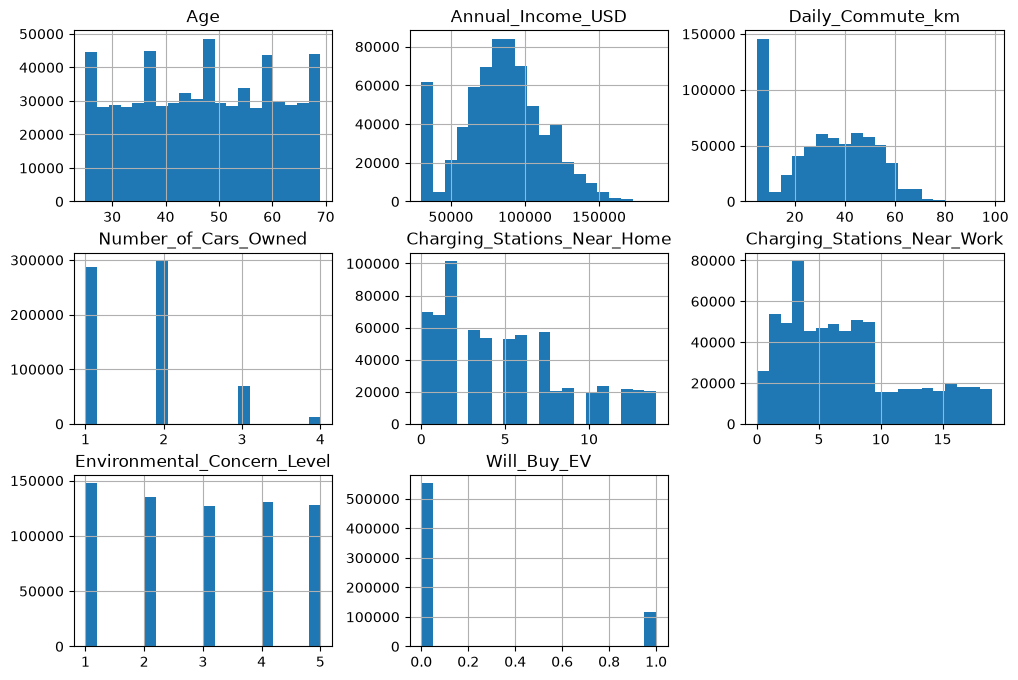

In [10]:
train_num.hist(bins=20, figsize=(12,8))
plt.show()

In [11]:
train_set, valid_set = train_test_split(train, test_size=0.15, random_state=42, stratify=train['Will_Buy_EV'])

for set_ in (train_set, valid_set):
    set_.drop("id", axis=1, inplace=True)
    

train = train_set.copy()
valid = valid_set.copy()

separando dados de treino e target

In [12]:
train_X = train.drop("Will_Buy_EV", axis=1)
train_y = train["Will_Buy_EV"].copy()
num_col.pop()

train_X_num = train_X[num_col]
train_X_cat = train_X[cat_col]

In [13]:
cat_pipeline = Pipeline([('cat_encoder', OneHotEncoder())])
num_pipeline = Pipeline([('std_scaler', StandardScaler())])

In [14]:
cat_attribs = list(train_X_cat)
num_attribs = list(train_X_num)

full_pipeline = ColumnTransformer([
                               ('num', num_pipeline, num_attribs),
                               ('cat', cat_pipeline, cat_attribs)
])

train_prepared = full_pipeline.fit_transform(train)

Logistic Regression

In [65]:
log_reg = LogisticRegression()
predicted_log_reg = cross_val_predict(log_reg, train_prepared, train_y, method='decision_function', cv=3)
classes_personalizadas_log_reg = (predicted_log_reg > 0).astype(int)


prec_pred_log_reg = precision_score(train_y, classes_personalizadas_log_reg)
rec_pred_log_reg = recall_score(train_y, classes_personalizadas_log_reg)
f1_pred_log_reg = f1_score(train_y, classes_personalizadas_log_reg)
roc_scr_log_reg = roc_auc_score(train_y, predicted_log_reg)


print(f'Precision Score - Logistic Regression: {prec_pred_log_reg}')
print(f'Recall Score - Logistic Regression: {rec_pred_log_reg}')
print(f'F1 Score - Logistic Regression: {f1_pred_log_reg}')
print(f'ROC AUC Score - Logistic Regression: {roc_scr_log_reg}')

Precision Score - Logistic Regression: 0.7179718831254682
Recall Score - Logistic Regression: 0.6565050069513007
F1 Score - Logistic Regression: 0.685864039657731
ROC AUC Score - Logistic Regression: 0.938063002635225


In [46]:
conf_mx_log_reg = confusion_matrix(train_y, classes_personalizadas_log_reg)
conf_mx_log_reg

array([[443505,  25598],
       [ 34096,  65166]])

In [39]:
fpr_log_reg, tpr_log_reg, thresholds_log_reg = roc_curve(train_y, predicted_log_reg)

Decision Tree - OVERFIT!!!

In [19]:
tree_clf = DecisionTreeClassifier()
predicted_tree_clf = cross_val_predict(tree_clf, train_prepared, train_y, cv=3)

prec_pred_tree_clf = precision_score(train_y, predicted_tree_clf)
rec_pred_tree_clf = recall_score(train_y, predicted_tree_clf)
f1_pred_tree_clf = f1_score(train_y, predicted_tree_clf)

print(f'Precision Score - Decision Trees: {prec_pred_tree_clf}')
print(f'Recall Score - Decision Trees: {rec_pred_tree_clf}')
print(f'F1 Score - Decision Trees: {f1_pred_tree_clf}')

Precision Score - Decision Trees: 0.5774843503536671
Recall Score - Decision Trees: 0.5864379117890028
F1 Score - Decision Trees: 0.5819266930916761


In [23]:
conf_mx_tree_clf = confusion_matrix(train_y, predicted_tree_clf)
conf_mx_tree_clf

array([[426513,  42590],
       [ 41051,  58211]])

Random Forest - OVERFIT!!!

In [47]:
rf_clf = RandomForestClassifier(random_state=42)
predicted_rf_clf = cross_val_predict(rf_clf, train_prepared, train_y, cv=3, method='predict_proba')
classes_rf_clf = (predicted_rf_clf[:, 1] >= 0.5).astype(int)

prec_pred_rf_clf = precision_score(train_y, classes_rf_clf)
rec_pred_rf_clf = recall_score(train_y, classes_rf_clf)
f1_pred_rf_clf = f1_score(train_y, classes_rf_clf)

print(f'Precision Score - Random Forest: {prec_pred_rf_clf}')
print(f'Recall Score - Random Forest: {rec_pred_rf_clf}')
print(f'F1 Score - Random Forest: {f1_pred_rf_clf}')

Precision Score - Random Forest: 0.7058663444477101
Recall Score - Random Forest: 0.6532509923233463
F1 Score - Random Forest: 0.6785402223675605


In [48]:
conf_mx_rf_clf = confusion_matrix(train_y, classes_rf_clf)
conf_mx_rf_clf

array([[442083,  27020],
       [ 34419,  64843]])

In [68]:
y_scores_rf = predicted_rf_clf[:, 1]
fpr_forest, tpr_forest, thresholds_forest = roc_curve(train_y, y_scores_rf)


roc_scr_rf_clf = roc_auc_score(train_y, y_scores_rf)
print(f'ROC AUC Score - Random Forest: {roc_scr_rf_clf}')

ROC AUC Score - Random Forest: 0.9319487979720361


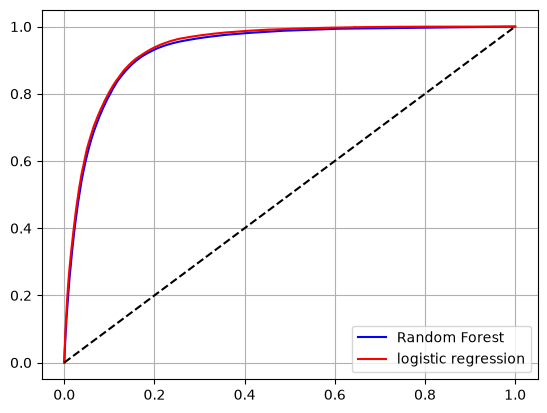

In [69]:

plt.plot(fpr_forest, tpr_forest, "b-", label="Random Forest")
plt.plot(fpr_log_reg, tpr_log_reg, "r-", label="logistic regression")
plt.plot([0,1], [0,1], 'k--')
plt.legend(loc="lower right")
plt.grid()
plt.show()